In [149]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

plt.tight_layout()

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2020-01-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# returns["change"] = np.log(returns["Close"]).diff()
returns["change"] = returns["Close"].diff()
returns = returns.dropna()
returns = returns[["Close", "change"]]
returns


[*********************100%***********************]  1 of 1 completed


Price,Close,change
Date,,
2020-01-03,3234.850098,-23.000000
2020-01-06,3246.280029,11.429932
2020-01-07,3237.179932,-9.100098
2020-01-08,3253.050049,15.870117
2020-01-09,3274.699951,21.649902
...,...,...
2025-05-01,5604.140137,35.080078
2025-05-02,5686.669922,82.529785
2025-05-05,5650.379883,-36.290039


<Figure size 640x480 with 0 Axes>

In [150]:
T = len(returns)
T

1343

In [151]:
# 예측할 미래 시점 개수
n_forecast = 30

# 전체 시점 구성 (과거 + 미래)
future_dates = pd.date_range(start=returns.index[-1] + pd.Timedelta(days=1), periods=n_forecast)
all_dates = returns.index.union(future_dates)

In [152]:
all_dates

DatetimeIndex(['2020-01-03', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10', '2020-01-13', '2020-01-14',
               '2020-01-15', '2020-01-16',
               ...
               '2025-05-28', '2025-05-29', '2025-05-30', '2025-05-31',
               '2025-06-01', '2025-06-02', '2025-06-03', '2025-06-04',
               '2025-06-05', '2025-06-06'],
              dtype='datetime64[ns]', length=1373, freq=None)

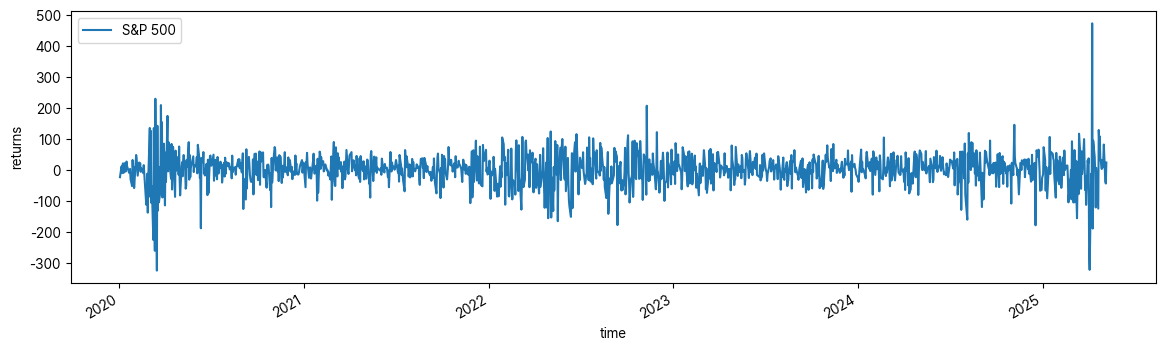

In [153]:
fig, ax = plt.subplots(figsize=(14, 4))
returns.plot(y="change", label="S&P 500", ax=ax)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [154]:
def make_stochastic_volatility_model(data, past_dates, future_dates):
    with pm.Model(coords={"time": past_dates, "forecast_time": future_dates}) as model:
        # sigma_rw 정의
        sigma_rw = pm.Exponential("sigma_rw", 10)

        # 로그 변동성 과정
        log_volatility = pm.GaussianRandomWalk("log_volatility", sigma=sigma_rw, dims="time")
        volatility = pm.Deterministic("volatility", pm.math.exp(log_volatility))
        nu = pm.Exponential("nu", 0.1)

        # 관측 모델
        pm.StudentT("returns", nu=nu, sigma=volatility[:T], observed=data["change"], dims="time")

        # 미래 관측 모델
        pm.StudentT("future_returns", nu=nu, sigma=volatility[-n_forecast:], dims="forecast_time")

        # pm.StudentT(
        #     "returns", nu=nu, lam=np.exp(-2 * volatility), observed=data["change"], dims="time"
        # )
    return model


forecast_model = make_stochastic_volatility_model(returns, past_dates=returns.index, future_dates=future_dates)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


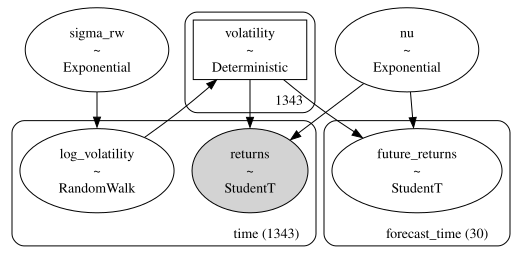

In [155]:
pm.model_to_graphviz(forecast_model)

In [156]:
with forecast_model:
    trace = pm.sample_prior_predictive(500)

prior_predictive = trace.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [future_returns, log_volatility, nu, returns, sigma_rw]


In [157]:
prior_predictive

<xarray.Dataset>
Dimensions:       (time: 1343, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 2020-01-03 2020-01-06 ... 2025-05-07
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 1.668e+62 -2.39e+05 ... -1.32e-14
Attributes:
    created_at:                 2025-05-08T07:17:01.713908
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

In [158]:
prior_predictive["returns"].shape

(1343, 500)

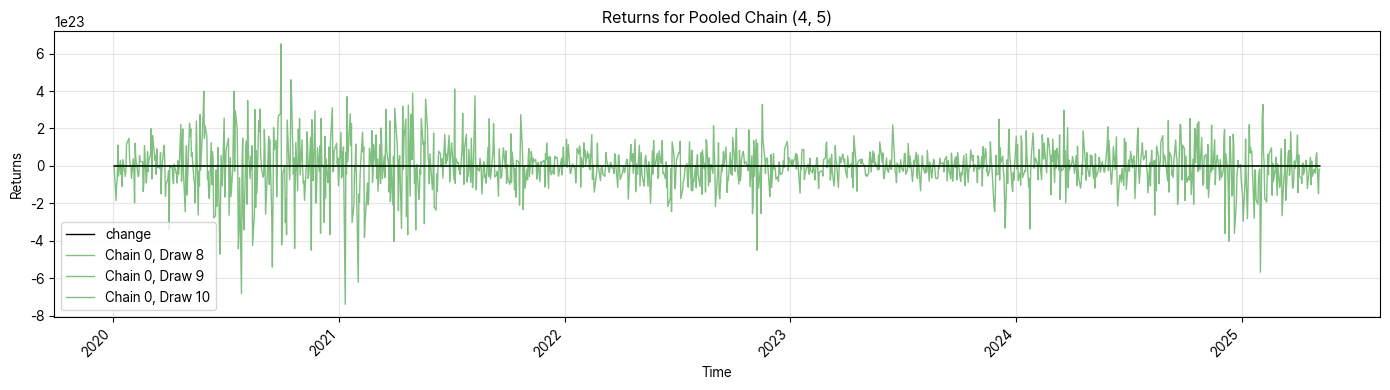

In [159]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(8, 11, None))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [184]:
with forecast_model:
    # sample = 6000
    sample = 2000
    trace.extend(pm.sample(sample, random_seed=42, target_accept=0.95, idata_kwargs={"log_likelihood": True}))


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_rw, log_volatility, nu, future_returns]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 520 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [185]:
from datetime import datetime
import arviz as az

# 현재 날짜와 시간
now = datetime.now()
formatted_time = now.strftime("%Y%m%d%H%M")  # 202505081200 형식

# 파일 저장
az.to_netcdf(trace, f"trace-{formatted_time}.nc")

'trace-202505080902.nc'

In [186]:
summary = az.summary(trace)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_rw,0.087,0.011,0.066,0.109,0.002,0.001,35.0,172.0,1.11
volatility[48],133.714,22.694,92.579,175.856,0.804,0.569,811.0,3115.0,1.01
volatility[46],126.961,21.849,90.025,169.816,0.699,0.501,1027.0,2779.0,1.01
volatility[45],122.760,21.249,86.552,163.926,0.657,0.470,1153.0,2563.0,1.01
volatility[44],118.123,20.354,82.627,155.936,0.567,0.406,1389.0,4513.0,1.01
...,...,...,...,...,...,...,...,...,...
log_volatility[2020-09-04T00:00:00.000000000],3.777,0.171,3.458,4.093,0.003,0.002,2858.0,5688.0,1.01
log_volatility[2020-06-11T00:00:00.000000000],3.908,0.181,3.574,4.246,0.003,0.002,2879.0,6185.0,1.01
log_volatility[2020-03-19T00:00:00.000000000],4.788,0.177,4.469,5.128,0.004,0.003,1941.0,4476.0,1.01
log_volatility[2020-03-18T00:00:00.000000000],4.820,0.173,4.488,5.136,0.004,0.003,1514.0,4268.0,1.01


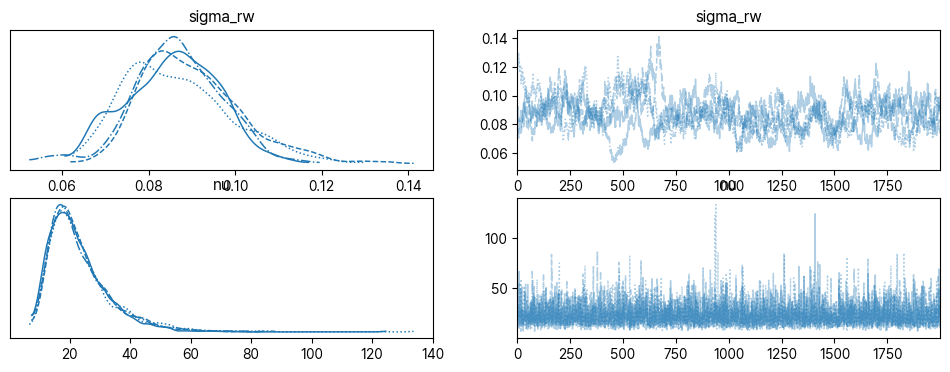

In [187]:
az.plot_trace(trace, var_names=["sigma_rw", "nu"]);

In [188]:

with forecast_model:
    forecast_returns = pm.sample_posterior_predictive(trace, var_names=["returns"])

Sampling: [returns]


In [189]:
forecast_returns


Inference data with groups:
	> posterior_predictive
	> observed_data

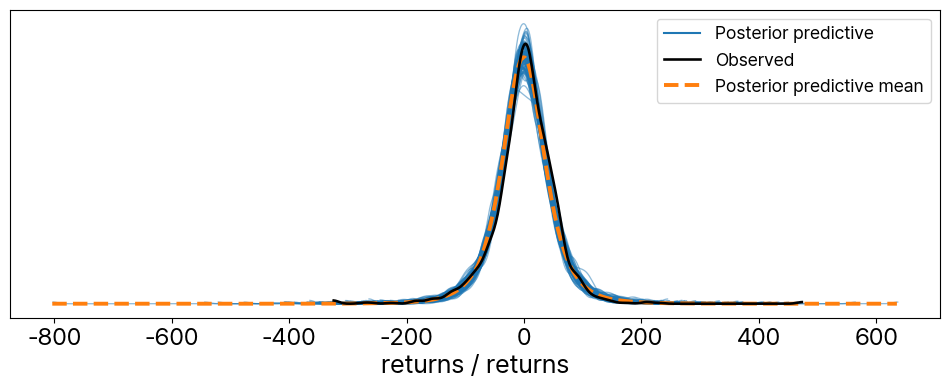

In [190]:
az.plot_ppc(forecast_returns, num_pp_samples=100, figsize=(12, 4), kind="kde", alpha=0.5);

<Axes: title={'center': 'returns / returns'}>

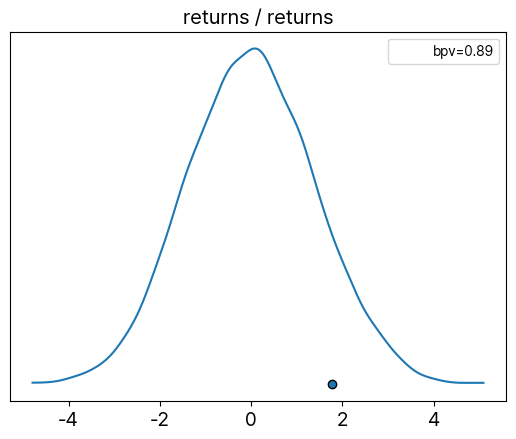

In [191]:
az.plot_bpv(forecast_returns, kind="t_stat", t_stat="mean")

In [193]:
az.loo(trace)

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 1343 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -6982.37    32.30
p_loo       68.55        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     1332   99.2%
 (0.5, 0.7]   (ok)         10    0.7%
   (0.7, 1]   (bad)         1    0.1%
   (1, Inf)   (very bad)    0    0.0%

In [194]:
# Posterior Predictive Sampling
with forecast_model:
    posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["future_returns"], random_seed=42)


Sampling: [future_returns]


In [195]:
posterior_predictive

Inference data with groups:
	> posterior_predictive
	> observed_data

In [196]:
posterior_predictive.posterior_predictive['future_returns'].shape

(4, 2000, 30)

In [197]:
posterior_predictive.posterior_predictive['future_returns'].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 100))

<xarray.DataArray 'future_returns' (forecast_time: 30, pooled_chain: 80)>
array([[  27.97237139, -126.69975831,  -43.93216439, ...,  -21.73553993,
           7.59594145, -153.06136284],
       [ -62.28099654, -112.73038358,  -55.84959429, ...,  124.53881263,
         -39.96674758,  217.30575329],
       [-105.34212224,   98.25065346,  -92.42345094, ...,   17.77696497,
        -120.29439714, -191.27497621],
       ...,
       [ -99.94435554,  -68.66215047,  -51.19829205, ...,  111.11876821,
         -26.79767569,  -73.02732479],
       [  29.19600744,   18.60832161,   22.97597028, ...,  127.55599232,
         153.11566818,  -55.63788385],
       [  60.75829436,   39.9070982 ,   42.33735415, ...,  195.43138812,
         -22.43966288,   -9.44763579]])
Coordinates:
  * forecast_time  (forecast_time) datetime64[ns] 2025-05-08 ... 2025-06-06
  * pooled_chain   (pooled_chain) object MultiIndex
  * chain          (pooled_chain) int64 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw           (pooled_chain) int64 0 100 200 300 ... 1600 1700 1800 1900

In [198]:

# 미래 시점 예측값 추출
future_samples = posterior_predictive.posterior_predictive['future_returns'].stack(
    pooled_chain=("chain", "draw")
).values.T

# 출력 형태 확인
print(f"Future Returns Shape: {future_samples.shape}")  # (1000, 30)


Future Returns Shape: (8000, 30)


In [199]:
future_return = posterior_predictive.posterior_predictive['future_returns'].stack(
    pooled_chain=("chain", "draw")
)

future_return.isel(pooled_chain=slice(None, None, 100))

<xarray.DataArray 'future_returns' (forecast_time: 30, pooled_chain: 80)>
array([[  27.97237139, -126.69975831,  -43.93216439, ...,  -21.73553993,
           7.59594145, -153.06136284],
       [ -62.28099654, -112.73038358,  -55.84959429, ...,  124.53881263,
         -39.96674758,  217.30575329],
       [-105.34212224,   98.25065346,  -92.42345094, ...,   17.77696497,
        -120.29439714, -191.27497621],
       ...,
       [ -99.94435554,  -68.66215047,  -51.19829205, ...,  111.11876821,
         -26.79767569,  -73.02732479],
       [  29.19600744,   18.60832161,   22.97597028, ...,  127.55599232,
         153.11566818,  -55.63788385],
       [  60.75829436,   39.9070982 ,   42.33735415, ...,  195.43138812,
         -22.43966288,   -9.44763579]])
Coordinates:
  * forecast_time  (forecast_time) datetime64[ns] 2025-05-08 ... 2025-06-06
  * pooled_chain   (pooled_chain) object MultiIndex
  * chain          (pooled_chain) int64 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw           (pooled_chain) int64 0 100 200 300 ... 1600 1700 1800 1900

In [200]:
future = trace.posterior['future_returns'].stack(
    pooled_chain=("chain", "draw")
)

future.isel(pooled_chain=slice(None, None, 100))

<xarray.DataArray 'future_returns' (forecast_time: 30, pooled_chain: 80)>
array([[  31.527937  ,  -51.87472327,   37.4812864 , ...,  -66.614529  ,
         -28.21098382, -224.39892635],
       [ -62.71066478,  220.83462634,  186.55681072, ...,   91.12683988,
         -14.47537763,  -38.45169045],
       [ 181.62501729,  286.22952628,  106.87558396, ...,  -17.40730984,
           8.67720773,  133.58527277],
       ...,
       [ 141.50707793,   16.18141969,  -65.35215627, ...,  -84.25563152,
        -112.25670601,   38.91280743],
       [ -10.06670103,  -59.31220614,  -14.48358471, ...,  -12.50746905,
         -36.33810857,    3.56260117],
       [ 134.95072524,   70.97697221,   41.55680593, ...,  -64.37621552,
          22.43782078, -115.02518185]])
Coordinates:
  * forecast_time  (forecast_time) datetime64[ns] 2025-05-08 ... 2025-06-06
  * pooled_chain   (pooled_chain) object MultiIndex
  * chain          (pooled_chain) int64 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw           (pooled_chain) int64 0 100 200 300 ... 1600 1700 1800 1900

In [201]:
future_samples

array([[  27.97237139,  -62.28099654, -105.34212224, ...,  -99.94435554,
          29.19600744,   60.75829436],
       [ -75.38972849,  -30.40119341,  -78.84144406, ...,    5.07843789,
        -134.25015402,  105.12861357],
       [  32.21058709,  161.82818047,   10.23290034, ...,  -62.50546627,
         103.73779244, -142.73695396],
       ...,
       [-175.98454606,  227.84243927,   34.36560205, ...,  -82.17047742,
           0.76822392, -103.21882851],
       [ -12.99863617,  -64.67942273,   57.06331269, ...,  -90.50247703,
          36.78637679, -115.22280111],
       [  91.03258882,  -96.42973289,   -7.71118432, ...,  -30.88252838,
         -29.9259938 ,  -58.99548677]])

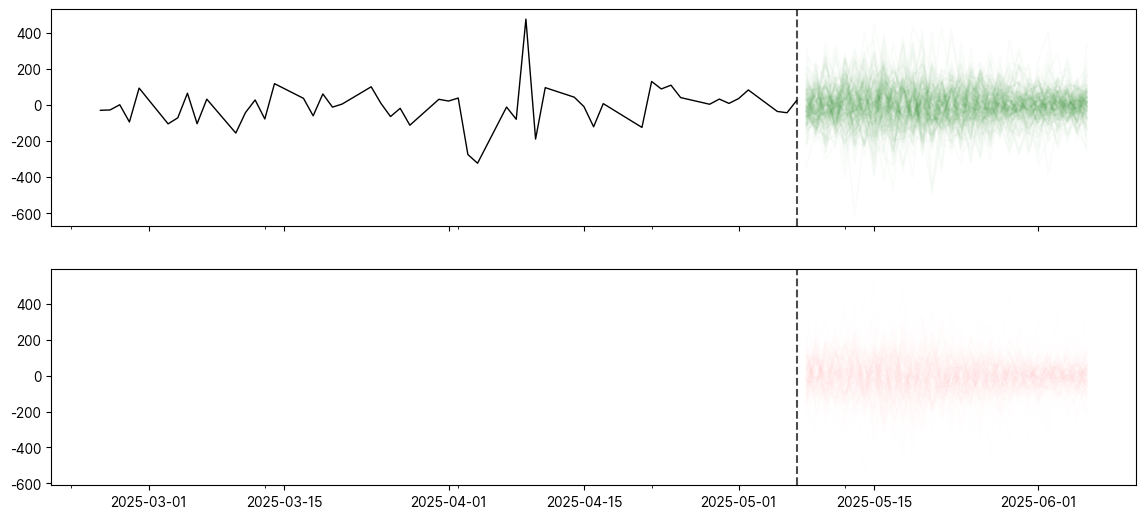

In [202]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["change"].iloc[-52:].plot(ax=axes[0], color="black", lw=1, label="Observed Returns");
axes[0].axvline(returns.index[-1], linestyle="--", color="black", alpha=0.7, label="Forecast Start");
axes[1].axvline(returns.index[-1], linestyle="--", color="black", alpha=0.7, label="Forecast Start");

y_vals = future_return.isel(pooled_chain=slice(None, None, 50))
x_vals = y_vals.forecast_time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.02);

y_vals = future.isel(pooled_chain=slice(None, None, 50))
x_vals = y_vals.forecast_time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.005);


In [125]:
trace

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [141]:
trace_test = trace.posterior

In [148]:
with forecast_model:
    trace.update(pm.sample_posterior_predictive(trace, var_names=["returns"], random_seed=42))

AttributeError: 'InferenceData' object has no attribute 'update'

In [147]:
trace

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [143]:
az.plot_ppc(trace_test, num_pp_samples=100)

TypeError: `data` argument must have the group "posterior_predictive" for ppcplot

In [115]:
az.to_netcdf(trace, "trace.nc")

'trace.nc'

In [116]:
with stochastic_vol_model:
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=rng))

posterior_predictive = idata.posterior_predictive.stack(pooled_chain=("chain", "draw"))

NameError: name 'rng' is not defined

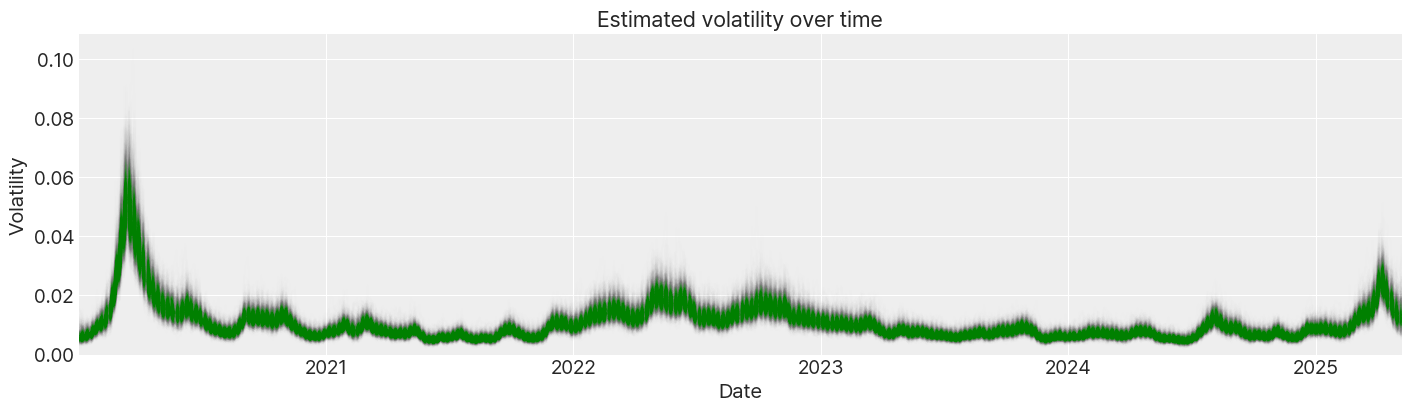

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

y_vals = posterior["exp_volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)

plt.plot(x_vals, y_vals, "g", alpha=0.002)
ax.set_xlim(x_vals.min(), x_vals.max())
ax.set_ylim(bottom=0)
ax.set(title="Estimated volatility over time", xlabel="Date", ylabel="Volatility");

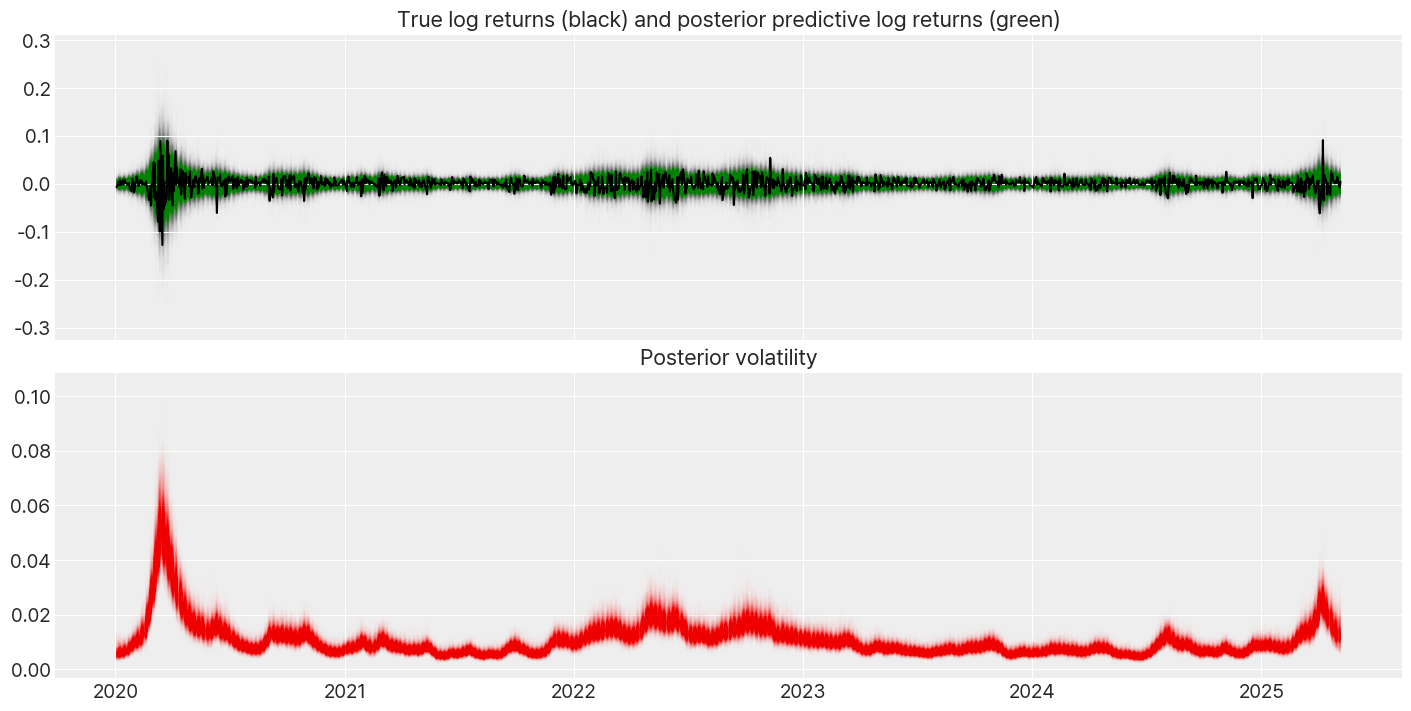

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["change"].plot(ax=axes[0], color="black")

y_vals = posterior["exp_volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.005)

y_vals = posterior_predictive["returns"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.005,
    zorder=-10)
axes[0].set_title("True log returns (black) and posterior predictive log returns (green)")
axes[1].set_title("Posterior volatility");